# Computación cuantica - Practica 4

Sosa Romo Juan Mario - 320051926

Ejecutar esta para tener ket y bra

$$
\newcommand{\ket}[1]{\left| #1 \right\rangle}
\newcommand{\bra}[1]{\left\langle #1 \right|}
\newcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}
$$


In [1]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 41.0 MB/s eta 0:00:00


In [3]:
# Basicos
import numpy as np
import matplotlib.pyplot as plt

# Qiskit
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error, kraus_error
from qiskit.visualization import plot_histogram

## 1. Ruido cuántico



### a) Contesta las siguientes preguntas

#### i) Demuestra que para las matrices de Paulli se cumple que:

$$\hat{\sigma}_j \hat{\sigma}_k = \delta _{jk} \hat{I}+ i \sum_{l=1}^3 \varepsilon _{jkl} \hat{\sigma}_l$$

---

Recordamos las matrices de Pauli son:
$$\hat{\sigma}_1 = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad \hat{\sigma}_2 = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}, \quad \hat{\sigma}_3 = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$

Y $\hat{I}$ es la matriz identidad de $2 \times 2$:
$$\hat{I} = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$$

---

**Demostración por Casos**

**Caso 1: Índices iguales ($j = k$)**

Cuando $j = k$, el delta de Kronecker vale $\delta_{jj} = 1$. El símbolo de Levi-Civita se anula porque contiene índices repetidos ($\varepsilon_{jjl} = 0$ para cualquier $l$).

La expresión general se reduce a:
$$\hat{\sigma}_j^2 = \hat{I}$$

Verificación por producto matricial directo:

* **Para $j=1$:**
  $$\hat{\sigma}_1^2 = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} = \hat{I}$$

* **Para $j=2$:**
  $$\hat{\sigma}_2^2 = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix} \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix} = \begin{pmatrix} -i^2 & 0 \\ 0 & -i^2 \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} = \hat{I}$$

* **Para $j=3$:**
  $$\hat{\sigma}_3^2 = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} = \hat{I}$$

---

**Caso 2: Índices diferentes ($j \neq k$)**

Cuando $j \neq k$, el delta de Kronecker se anula ($\delta_{jk} = 0$). En el término del símbolo de Levi-Civita, la sumatoria sobre $l$ colapsa a un único término debido a que $\varepsilon_{jkl}$ solo es distinto de cero cuando $l$ toma el valor del tercer índice restante.

La expresión se reduce a:
$$\hat{\sigma}_j \hat{\sigma}_k = i \varepsilon_{jkl} \hat{\sigma}_l$$

Verificación de las permutaciones independientes:

* **Permutación cíclica ($j=1, k=2 \implies l=3$ con $\varepsilon_{123} = 1$):**
  $$\hat{\sigma}_1 \hat{\sigma}_2 = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix} = \begin{pmatrix} i & 0 \\ 0 & -i \end{pmatrix} = i \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} = i \hat{\sigma}_3$$

* **Permutación anticíclica ($j=2, k=1 \implies l=3$ con $\varepsilon_{213} = -1$):**
  $$\hat{\sigma}_2 \hat{\sigma}_1 = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix} \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} = \begin{pmatrix} -i & 0 \\ 0 & i \end{pmatrix} = -i \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} = -i \hat{\sigma}_3$$

* **Permutación cíclica ($j=2, k=3 \implies l=1$ con $\varepsilon_{231} = 1$):**
  $$\hat{\sigma}_2 \hat{\sigma}_3 = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix} \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} = \begin{pmatrix} 0 & i \\ i & 0 \end{pmatrix} = i \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} = i \hat{\sigma}_1$$

* **Permutación cíclica ($j=3, k=1 \implies l=2$ con $\varepsilon_{312} = 1$):**
  $$\hat{\sigma}_3 \hat{\sigma}_1 = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} = \begin{pmatrix} 0 & 1 \\ -1 & 0 \end{pmatrix} = i \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix} = i \hat{\sigma}_2$$

Las combinaciones restantes ($j=3, k=2$ y $j=1, k=3$) se cumplen de manera similar

---

**Conclusión**

Al ser válidos de forma exhaustiva tanto el caso $j=k$ como el caso $j \neq k$, la identidad general queda demostrada para cualquier combinación de índices en el espacio tridimensional.

#### ii) Demuestra que:

$$\frac{I}{2} = \frac{\rho + X \rho X + Y \rho Y + Z \rho Z }{4}$$

y con eso explicar los canales de Kraus del Depolarizing Channel

---

**Demostración**

Cualquier matriz de densidad de un qubit $\rho$ se puede expresar en la base de Pauli (utilizando el vector de Bloch) como:

$$\rho = \frac{1}{2} (I + r_x X + r_y Y + r_z Z)$$

Donde $\vec{r} = (r_x, r_y, r_z)$.

Calculamos los términos $X\rho X$, $Y\rho Y$ y $Z\rho Z$. Para esto ocupamos las propiedades de las matrices de Pauli: $X^2=Y^2=Z^2=I$, y su anticonmutación $XY = -YX \implies XYX = -Y$.

*   **Para $X\rho X$:**
    
    $$X\rho X = \frac{1}{2} (XIX + r_x XXX + r_y XYX + r_z XZX) = \frac{1}{2} (I + r_x X - r_y Y - r_z Z)$$

*   **Para $Y\rho Y$:**
    
    $$Y\rho Y = \frac{1}{2} (YIY + r_x YXY + r_y YYY + r_z YZY) = \frac{1}{2} (I - r_x X + r_y Y - r_z Z)$$

*   **Para $Z\rho Z$:**
    
    $$Z\rho Z = \frac{1}{2} (ZIZ + r_x ZXZ + r_y ZYZ + r_z ZZZ) = \frac{1}{2} (I - r_x X - r_y Y + r_z Z)$$

Sumamos los cuatro términos ($\rho + X\rho X + Y\rho Y + Z\rho Z$).

Al sumar, puedes observar que los coeficientes vectoriales se cancelan:
*   Para $X$: $r_x + r_x - r_x - r_x = 0$
*   Para $Y$: $r_y - r_y + r_y - r_y = 0$
*   Para $Z$: $r_z - r_z - r_z + r_z = 0$

Mientras que el término de la identidad se suma cuatro veces:
*   Para $I$: $I + I + I + I = 4I$

Por lo tanto:

$$\rho + X\rho X + Y\rho Y + Z\rho Z = \frac{1}{2}(4I) = 2I$$

Dividiendo ambos lados entre 4, llegamos directamente al resultado:

$$\frac{\rho + X \rho X + Y \rho Y + Z \rho Z }{4} = \frac{2I}{4} = \frac{I}{2}$$

---

**Los Canales de Kraus y el Depolarizing Channel**

La ecuación anterior demuestra matemáticamente el caso extremo del **canal despolarizador**. El estado final $\frac{I}{2}$ corresponde al estado máximamente mixto, indicando que el qubit perdió toda su información cuántica.

Un canal cuántico se describe mediante operadores de Kraus $E_k$ que cumplen la relación de completitud $\sum E_k^\dagger E_k = I$. La evolución del estado se modela como $\mathcal{E}(\rho) = \sum E_k \rho E_k^\dagger$.

Si reescribimos la ecuación que acabamos de demostrar en esa forma:

$$\mathcal{E}(\rho) = \frac{1}{4}\rho + \frac{1}{4}X\rho X + \frac{1}{4}Y\rho Y + \frac{1}{4}Z\rho Z$$

Podemos identificar los operadores de Kraus de este canal:

$$E_0 = \frac{1}{2}I, \quad E_1 = \frac{1}{2}X, \quad E_2 = \frac{1}{2}Y, \quad E_3 = \frac{1}{2}Z$$

**Interpretación física en la Computación Cuántica:**

Esto define el mecanismo de despolarización completa. Aplicar este canal equivale a someter el qubit a uno de los cuatro escenarios posibles, todos con probabilidad uniforme ($p = 1/4$):

1.  El qubit se mantiene intacto (operador $I$).
2.  Sufre un error de bit-flip (operador $X$).
3.  Sufre un error combinado de bit-flip y phase-flip (operador $Y$).
4.  Sufre un error de phase-flip (operador $Z$).

En simulaciones, el canal despolarizador se puede escribir como:

$$
\mathcal{E}_p(\rho) = (1-p)\rho + p\frac{I}{2}
$$

donde (p) representa la probabilidad de que ocurra ruido en el qubit. Usando la identidad que demostramos aquí, se pueden obtener los operadores de Kraus para cualquier valor de (p) ajustando cómo se reparten las probabilidades entre los distintos operadores.


### b) Corre Berstein Vazirani para el string que tu desees. Pero implementa los siguientes modelos de ruido



#### i) Bit-Flip con $p=0.2$ en las compuertas H

---

Resultados con ruido: {'010': 15, '000': 39, '110': 31, '100': 117, '011': 36, '111': 140, '001': 121, '101': 501}


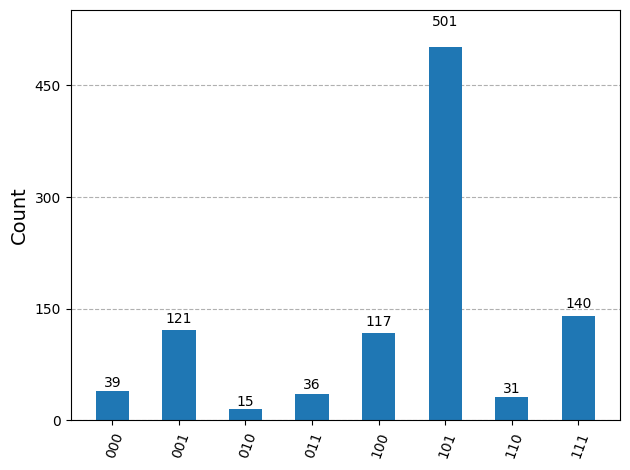

In [ ]:
secret_string = "101"
n = len(secret_string)

# Circuito de Bernstein-Vazirani
qc = QuantumCircuit(n + 1, n)

# Qubit auxiliar en el estado |->
qc.x(n)
qc.h(n)
qc.barrier()

# H a los qubits de datos
for i in range(n):
    qc.h(i)
qc.barrier()

# Oráculo
# Invertimos el string porque IBM ordena los qubits de q_n a q_0
secret_string_rev = secret_string[::-1]
for i, bit in enumerate(secret_string_rev):
    if bit == '1':
        qc.cx(i, n)
qc.barrier()

# H finales y medimos
for i in range(n):
    qc.h(i)
    qc.measure(i, i)

# Ruido
p_error = 0.2

# Error de bit-flip: aplica X con prob p, o Identidad con prob 1-p
bit_flip = pauli_error([('X', p_error), ('I', 1 - p_error)])

noise_model = NoiseModel()

# Aplicamos el error a las compuertas H
noise_model.add_all_qubit_quantum_error(bit_flip, ['h'])

# Agregamos ruido al simulador
sim = AerSimulator(noise_model=noise_model)

# Transpilar y ejecutar
qc_transpiled = transpile(qc, sim)
result = sim.run(qc_transpiled, shots=1000).result()
counts = result.get_counts()

# Mostrar resultados
print("Resultados con ruido:", counts)
plot_histogram(counts)

'''
Vemos que aun con poca probabilidad, el error introduce bastante cambio
respecto al circuito ideal, aun asi se puede distinguir la cadena secreta.
'''

#### ii) Phase flip en todas las compuertas unitarias

Resultados con Phase Flip: {'110': 12, '011': 15, '111': 52, '000': 82, '010': 15, '001': 176, '100': 118, '101': 530}


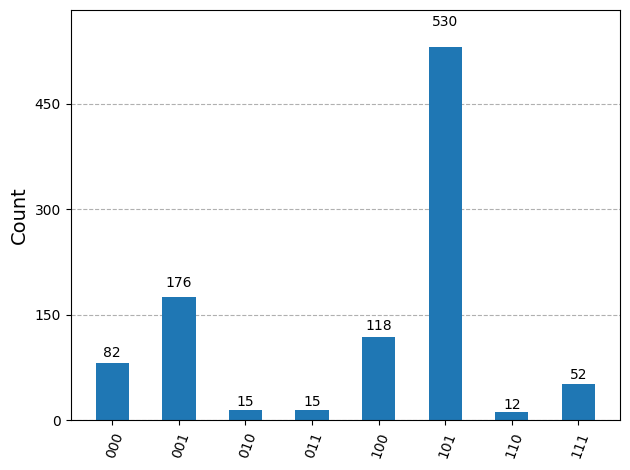

In [ ]:
p_phase = 0.1

# Error Z de un qubit y error ZZ para compuertas de dos qubits
phase_error_1q = pauli_error([('Z', p_phase), ('I', 1 - p_phase)])
phase_error_2q = phase_error_1q.tensor(phase_error_1q)

# Aplicamos los errores
noise_model_phase = NoiseModel()
noise_model_phase.add_all_qubit_quantum_error(phase_error_1q, ['h', 'x', 'id', 'u1', 'u2', 'u3'])
noise_model_phase.add_all_qubit_quantum_error(phase_error_2q, ['cx'])

sim_phase = AerSimulator(noise_model=noise_model_phase)

# usamos el qc de i)
qc_transpiled_phase = transpile(qc, sim_phase)
result_phase = sim_phase.run(qc_transpiled_phase, shots=1000).result()

counts_phase = result_phase.get_counts()
print("Resultados con Phase Flip:", counts_phase)
plot_histogram(counts_phase)

# los resultados son similares

#### iii) Depolarizing channel con probabilidad p=0.01 en todas las compuertas

---

Resultados con Depolarizing Channel: {'010': 1, '000': 7, '111': 13, '001': 25, '100': 14, '101': 940}


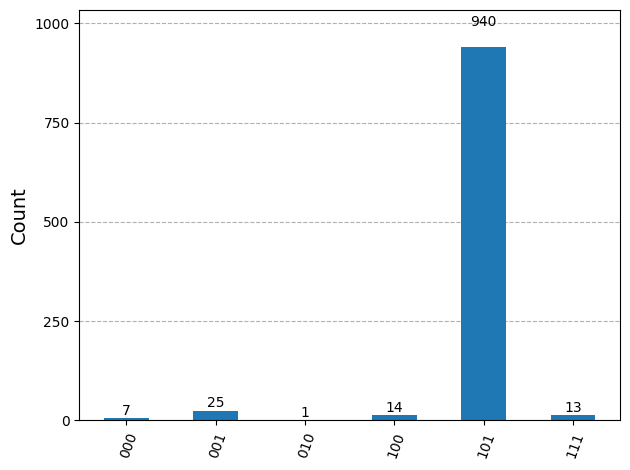

In [ ]:
p_depol = 0.01
depol_error_1q = depolarizing_error(p_depol, 1)
depol_error_2q = depolarizing_error(p_depol, 2)

# agregamos el error
noise_model_depol = NoiseModel()
noise_model_depol.add_all_qubit_quantum_error(depol_error_1q, ['h', 'x', 'id', 'u1', 'u2', 'u3'])
noise_model_depol.add_all_qubit_quantum_error(depol_error_2q, ['cx'])

sim_depol = AerSimulator(noise_model=noise_model_depol)

qc_transpiled_depol = transpile(qc, sim_depol)
result_depol = sim_depol.run(qc_transpiled_depol, shots=1000).result()

counts_depol = result_depol.get_counts()
print("Resultados con Depolarizing Channel:", counts_depol)
plot_histogram(counts_depol)

# obviamente, se comporta mejor aqui porque la probabilidad de fallo es mucho menor

**i. Bit-Flip con \(p = 0.2\) en las compuertas H**

En este caso el resultado correcto `101` sigue siendo el más frecuente con 501 conteos, pero aparecen muchos otros estados debido al ruido. El error bit-flip provoca cambios directos en los qubits, por lo que la distribución de resultados se dispersa bastante.

**ii. Phase Flip en todas las compuertas unitarias**

El estado `101` sigue dominando con 530 conteos, aunque también aparecen resultados incorrectos como `001` y `100`. Este tipo de ruido afecta principalmente las fases del sistema y modifica la interferencia cuántica del circuito.

**iii. Depolarizing Channel con \(p = 0.01\)**

En este caso el resultado es mucho más cercano al ideal. El estado `101` aparece 940 veces de 1000 ejecuciones, lo que indica que el ruido introducido es pequeño y el circuito mantiene un comportamiento estable.

### c) ¿Existe algún canal de ruido que no se encuentre entre los primeros que mencionamos en la sesión? Investigalo, explicalo e implementalo utilizando los operadores de Kraus que correspondan a dicho canal y explica los resultados

**Canal de Amortiguamiento de Amplitud (Amplitude Damping Channel)**

Es un canal de ruido que modela la pérdida o disipación de energía de un sistema cuántico hacia su entorno. Físicamente, representa procesos como la emisión espontánea en átomos o la relajación térmica en circuitos superconductores.

El Amplitude Damping es asimétrico: un qubit en el estado excitado $|1\rangle$ decae al estado base $|0\rangle$ con una probabilidad $\gamma$. Si el qubit ya está en el estado $|0\rangle$, no sufre ningún cambio.

---

**Operadores de Kraus**

Los operadores para este canal, parametrizados por la probabilidad de decaimiento $\gamma$, son:

$$E_0 = \begin{pmatrix} 1 & 0 \\ 0 & \sqrt{1-\gamma} \end{pmatrix}, \quad E_1 = \begin{pmatrix} 0 & \sqrt{\gamma} \\ 0 & 0 \end{pmatrix}$$

Donde $E_1$ representa el salto cuántico o decaimiento ($|1\rangle \to |0\rangle$). El operador $E_0$ representa la evolución del estado cuando no ocurre el decaimiento, pero que reduce la amplitud de la componente $|1\rangle$ para mantener la traza de la matriz de densidad igual a 1. Cumplen con $\sum E_k^\dagger E_k = I$.

---

Resultados con Amplitude Damping: {'110': 5, '010': 4, '000': 64, '011': 4, '111': 28, '100': 144, '001': 137, '101': 614}


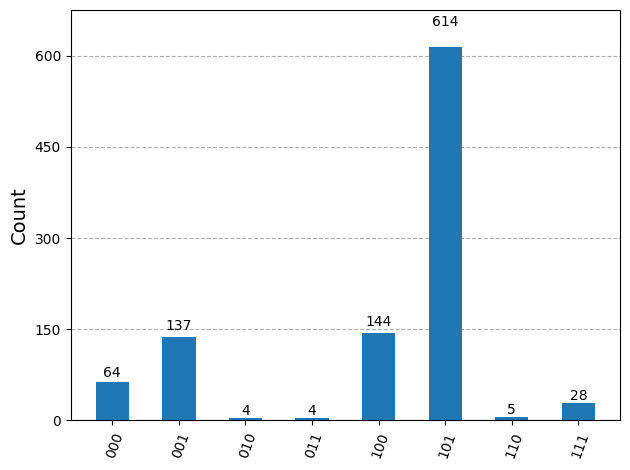

In [ ]:
# Probabilidad de decaimiento
gamma = 0.15

# Definir los operadores de Kraus
E0 = np.array([[1, 0],
               [0, np.sqrt(1 - gamma)]])

E1 = np.array([[0, np.sqrt(gamma)],
               [0, 0]])

# Crear el error cuántico a partir de las matrices
amp_damping_error = kraus_error([E0, E1])

noise_model_amp = NoiseModel()
# Lo aplicamos a todas las compuertas unitarias de 1 qubit
noise_model_amp.add_all_qubit_quantum_error(amp_damping_error, ['h', 'x', 'id', 'u1', 'u2', 'u3'])

sim_amp = AerSimulator(noise_model=noise_model_amp)

# Asumimos que el QuantumCircuit 'qc' sigue en memoria
qc_transpiled_amp = transpile(qc, sim_amp)
result_amp = sim_amp.run(qc_transpiled_amp, shots=1000).result()

counts_amp = result_amp.get_counts()
print("Resultados con Amplitude Damping:", counts_amp)
plot_histogram(counts_amp)

Al aplicar el *Amplitude Damping* observamos lo siguiente:

1. El estado `101` sigue siendo el pico más alto
2. Hay conteos en otros puntos, pero no estan distribuidos uniformemente como en el *Depolarizing Channel*.
3. Los errores estarán fuertemente sesgados hacia estados con más bits en `0`. Verás picos secundarios notables en los estados `001`, `100` y el estado base `000`.

Esto ocurre porque los qubits que idealmente colapsarían a $|1\rangle$ durante la ejecución pierden energía y caen a $|0\rangle$.

## 2. Grover

### a) Aplica el algoritmo de Grover para |1111⟩ y para |1110⟩ SIN UTILIZAR las funciones dadas para el oráculo de grover y para el difusor de grover, si no explicando desde 0 como realizaste el cambio de base para poder simular la operación del oráculo y difusor. Realiza las iteraciones necesarias.

Para 4 qubits, el espacio de búsqueda es $N=16$. El número de iteraciones óptimas se calcula con $\lfloor \frac{\pi}{4}\sqrt{16} \rfloor = 3$.

La idea del oráculo es invertir la fase del estado objetivo. Para lograr un Multiple-Controlled Z (MCZ) utilizando solo compuertas básicas y la Multiple-Controlled X (MCX), aplicamos un cambio de base. Sabemos que $HXH = Z$. Por lo tanto, si aplicamos una compuerta Hadamard al qubit objetivo, luego una MCX controlada por el resto de los qubits, y finalmente otra Hadamard, logramos el cambio de fase.

Para el estado |1111> aplicamos el MCZ. Para el estado |1110> (donde el qubit menos significativo $q_0$ es 0 en el ordenamiento de Qiskit), aplicamos el cambio de base aplicando una X antes y despues de MCZ.


Luego se amplifica la amplitud del estado marcado realizando una inversión sobre la media. Esto se logra cambiando a la base de superposición con Hadamards en todos los qubits, aplicando un cambio de fase al estado |0000> (envolviendo todos los qubits con X y aplicando nuestro MCZ), deshaciendo las X y finalmente regresando a la base computacional con Hadamards.

In [ ]:
def oraculo_1111(qc):
    # Cambio de base
    qc.h(3)
    qc.mcx([0, 1, 2], 3)
    qc.h(3)

def oraculo_1110(qc):
    # q0 lo cambiamos a 1 temporalmente
    qc.x(0)
    qc.h(3)
    qc.mcx([0, 1, 2], 3)
    qc.h(3)
    qc.x(0)

def difusor(qc):
    # Cambio a la base
    for i in range(4):
        qc.h(i)
        qc.x(i)

    # MCZ a |0000>
    qc.h(3)
    qc.mcx([0, 1, 2], 3)
    qc.h(3)

    # Deshacer cambio de base
    for i in range(4):
        qc.x(i)
        qc.h(i)

# |1111>
qc_1111 = QuantumCircuit(4, 4)
for i in range(4): qc_1111.h(i)

for _ in range(3):
    oraculo_1111(qc_1111)
    difusor(qc_1111)

qc_1111.measure(range(4), range(4))

# |1110>
qc_1110 = QuantumCircuit(4, 4)
for i in range(4): qc_1110.h(i)

for _ in range(3):
    oraculo_1110(qc_1110)
    difusor(qc_1110)

qc_1110.measure(range(4), range(4))

sim = AerSimulator()
counts_1111 = sim.run(transpile(qc_1111, sim), shots=1024).result().get_counts()
counts_1110 = sim.run(transpile(qc_1110, sim), shots=1024).result().get_counts()

print("Resultados |1111>:", counts_1111)
print("Resultados |1110>:", counts_1110)

Resultados |1111>: {'1000': 2, '1111': 983, '0001': 2, '1011': 2, '0011': 3, '0111': 6, '0000': 4, '0010': 7, '1101': 3, '1010': 4, '0101': 3, '1001': 1, '1100': 2, '0100': 2}
Resultados |1110>: {'0100': 1, '1010': 2, '1100': 2, '1001': 2, '0001': 2, '1111': 3, '0110': 5, '0111': 2, '1011': 4, '0011': 2, '0010': 2, '0000': 3, '1110': 994}


### b) Corre el algoritmo de grover para encontrar el numero de tu preferencia, pero opera el Operador de grover mayor cantidad de veces de las que la teoría mencionada en el Notebook predice. ¿Que pasa? ¿Hay algún cambio en las probabilidades? Explica por que se da el cambio que observas en las probabilidades

---

Si iteras el operador de Grover más veces de las que la teoría predice, la probabilidad de medir el estado objetivo disminuye.

El algoritmo de Grover no acumula probabilidad infinitamente. Es una rotación geométrica del vector de estado. Cada aplicación del operador de Grover rota el estado un ángulo $\theta$ acercándolo al estado objetivo. Si superas el número óptimo de iteraciones $m \approx \frac{\pi}{4}\sqrt{N}$, el vector sobrepasa el estado objetivo y comienza a rotar hacia los estados ortogonales. Las probabilidades oscilan siguiendo una función seno cuadrado.

In [ ]:
def oraculo_1010(qc):
    qc.x([0, 2])
    qc.h(3)
    qc.mcx([0, 1, 2], 3)
    qc.h(3)
    qc.x([0, 2])

qc_over = QuantumCircuit(4, 4)
for i in range(4): qc_over.h(i)

# Aplicamos 7 iteraciones
iteraciones_excesivas = 7
for _ in range(iteraciones_excesivas):
    oraculo_1010(qc_over)
    difusor(qc_over)

qc_over.measure(range(4), range(4))

counts_over = sim.run(transpile(qc_over, sim), shots=1024).result().get_counts()
print(f"Resultados |1010> con {iteraciones_excesivas} iteraciones:", counts_over)

'''
Seguimos pudiendo identificar la cadena pero ya la distribucion de
probabilidades no es tan buena
'''

Resultados |1010> con 7 iteraciones: {'1110': 49, '1100': 44, '1101': 38, '0000': 39, '0010': 38, '0001': 49, '1111': 43, '1011': 37, '0111': 39, '0011': 42, '1010': 358, '0110': 49, '1000': 55, '0101': 50, '1001': 50, '0100': 44}


### c) Implementa algún modelo de ruido cuántico a las compuertas de 1 Qubit en el algoritmo de Grover, con probabilidad p=0.01 y visualiza como cambia la implementación del algoritmo y si ahora funciona correctamente. Haz las comparaciones utilizando histogramas y explicando por que crees que mediste lo que mediste. ¿Es el algoritmo de Grover un algoritmo tangible para sistemas con ruido?



Resultados |1111> con ruido (p=0.01): {'1101': 31, '1100': 19, '1111': 579, '0001': 33, '1011': 33, '0011': 28, '0111': 59, '1110': 36, '0000': 24, '0010': 29, '0100': 26, '0110': 29, '1000': 29, '0101': 18, '1001': 22, '1010': 29}


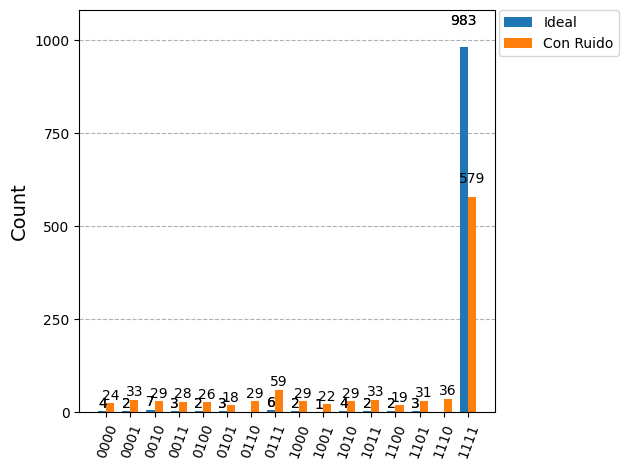

In [ ]:
p_error = 0.01
error_1q = depolarizing_error(p_error, 1)

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(error_1q, ['u1', 'u2', 'u3', 'h', 'x', 'rz', 'sx'])

sim_noise = AerSimulator(noise_model=noise_model)

qc_ruido = QuantumCircuit(4, 4)
for i in range(4): qc_ruido.h(i)

for _ in range(3): # Usamos las 3 iteraciones óptimas
    oraculo_1111(qc_ruido)
    difusor(qc_ruido)

qc_ruido.measure(range(4), range(4))

qc_transpiled_noise = transpile(qc_ruido, sim_noise)
counts_noise = sim_noise.run(qc_transpiled_noise, shots=1024).result().get_counts()

print("Resultados |1111> con ruido (p=0.01):", counts_noise)
plot_histogram([counts_1111, counts_noise], legend=['Ideal', 'Con Ruido'])

Se puede ver que el algoritmo sigue funcionando porque `1111` continúa siendo el resultado más frecuente. Sin embargo, al agregar ruido, los resultados correctos disminuyen bastante: en el caso ideal hubo 983 mediciones de `1111`, mientras que con ruido bajó a 585 y comenzaron a aparecer otros estados.

Esto pasa porque Grover depende mucho de la interferencia cuántica y de que las amplitudes se mantengan correctas durante el circuito. Cuando hay ruido, esa amplificación ya no ocurre de manera perfecta y parte de la probabilidad se distribuye en resultados incorrectos.

Considero que Grover sí puede funcionar en sistemas con ruido pequeño o moderado, pero conforme aumentan los errores, el algoritmo pierde precisión rápidamente. Por eso actualmente es más viable en sistemas pequeños o con hardware cuántico más estable.

De hecho si probamos con 0.04, el resultado ya es practicamente inutil.

## 3. Caminatas Cuánticas

### a) Simula caminatas cuánticas para 10, 20, 50 y 100 pasos. Y comparala con caminatas clásicas similares con la misma cantidad de pasos. Explicame como se visualizan, si son parecidas o diferentes. Utiliza gráficas o histogramas que ayuden a entender la intuición.

---

Vamos a utilizar NumPy porque 100 pasos en circuitos seria medio complejo, igualmente la idea es hacer la simulacion y sabemos que son diferentes puesto a que la cuantica tiene fases negativas por lo tanto interferencia destructiva mientras que en la clasica solo se suma.

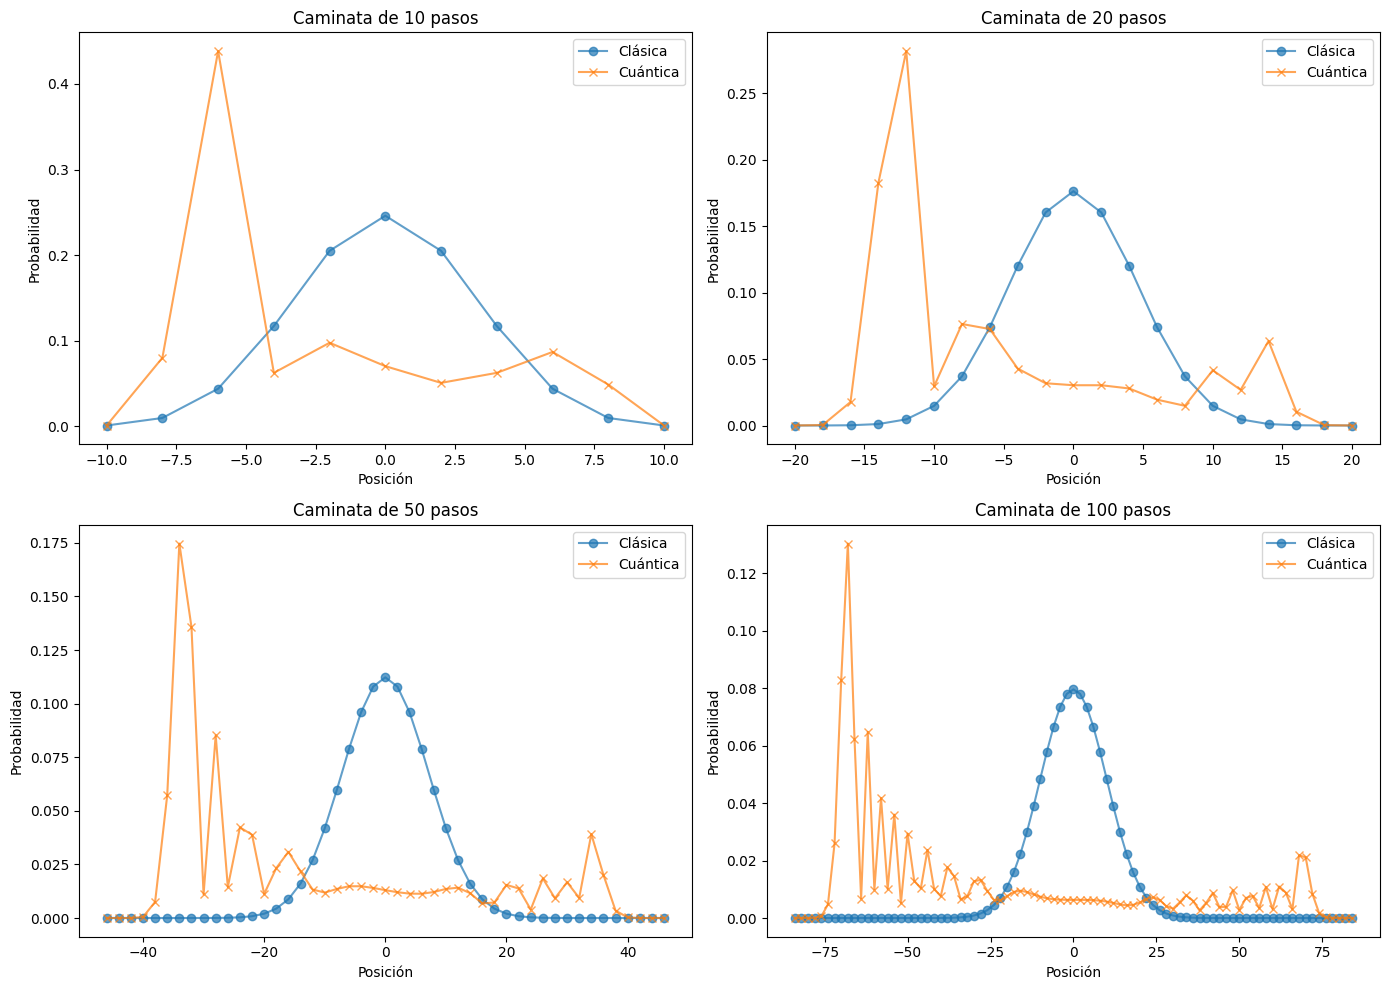

In [ ]:
def simular_caminatas(steps):
    # Clásica
    # -steps a +steps
    pos_c = np.zeros(2 * steps + 1)
    pos_c[steps] = 1.0

    for _ in range(steps):
        new_pos = np.zeros_like(pos_c)
        # coin flip
        new_pos[:-1] += pos_c[1:] * 0.5
        new_pos[1:] += pos_c[:-1] * 0.5
        pos_c = new_pos

    # Cuántica
    """
    Estado: [posicion, estado_moneda]
    Moneda: {0:izq, 1:der}
    """
    amps = np.zeros((2 * steps + 1, 2), dtype=complex)
    amps[steps, 0] = 1.0  # Inicia en el centro con la moneda en |0>

    H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]])

    for _ in range(steps):
        # 1. Tirar la moneda H a cada nodo
        amps = np.einsum('ij, kj -> ki', H, amps)

        # 2. Shift
        new_amps = np.zeros_like(amps)

        # Moneda |0> desplaza a la izquierda
        new_amps[:-1, 0] = amps[1:, 0]
        # Moneda |1> desplaza a la derecha
        new_amps[1:, 1] = amps[:-1, 1]

        amps = new_amps

    # Probabilidad total = |amp_izq|^2 + |amp_der|^2
    probs_q = np.sum(np.abs(amps)**2, axis=1)

    return pos_c, probs_q

# Simular y graficar
step_counts = [10, 20, 50, 100]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, steps in zip(axes.flatten(), step_counts):
    cl, qu = simular_caminatas(steps)
    x = np.arange(-steps, steps + 1)

    valid = np.abs(cl) + qu > 1e-10

    ax.plot(x[valid], cl[valid], 'o-', label='Clásica', alpha=0.7)
    ax.plot(x[valid], qu[valid], 'x-', label='Cuántica', alpha=0.7)
    ax.set_title(f'Caminata de {steps} pasos')
    ax.set_xlabel('Posición')
    ax.set_ylabel('Probabilidad')
    ax.legend()

plt.tight_layout()
plt.show()

### b) Digamos que quisiera correr una caminata cuántica en hardware real, de modo que quisiera hacer una caminata de unos 3 pasos. ¿Es eso posible?. Investiga como implementarla con Adders y simula una caminata de 3 pasos en Qiskit. Tienes permiso de utilizar IA para este ejercicio, pero debes de explicar con detalle cada cosa que la IA genere y realizar citas a fuentes reales que fundamenten lo que estas realizando. No dejes ningun cabo suelto.

---


Para implementar la caminata de 3 pasos, utilizamos 4 qubits: 1 qubit que actúa como la moneda y 3 qubits para almacenar la posición en binario. El operador de desplazamiento se divide en dos sumadores condicionales.

**1. Incrementador (Shift Right)**

Si la moneda está en el estado $|1\rangle$, sumamos $+1$ a la posición. En lógica digital, sumar 1 implica invertir un bit solo si todos los bits menos significativos son 1. Implementamos esto usando compuertas multicontroladas (MCX, CCX) con la moneda como control. Es crítico aplicar las compuertas desde el bit más significativo (MSB) hacia el menos significativo (LSB) para no destruir la información del acarreo (carry) antes de usarla.

**2. Decrementador (Shift Left)**

Si la moneda está en $|0\rangle$, restamos $-1$. Usamos la aritmética de complemento a dos. Negamos todos los qubits de posición con compuertas X, reutilizamos el bloque incrementador (+1) y volvemos a negar todo. Condicionamos este bloque al estado $|0\rangle$ aplicando compuertas X al qubit de la moneda al inicio y al final.

**3. Ejecución y Lectura**
Iteramos este proceso 3 veces. En cada paso, aplicamos una compuerta Hadamard a la moneda para inducir la superposición, seguida de los operadores de desplazamiento. Dado que están condicionados a estados ortogonales, operan simultáneamente en la superposición. Al medir, las posiciones negativas resultan en un "underflow" binario por la naturaleza modular del registro (por ejemplo, el estado $-1$ se lee como `111` y el $-2$ como `110`).

**Referencias**

[1] IBM Quantum. (s.f.). *Quantum Arithmetic*. Qiskit Textbook. Recuperado de https://qiskit.org/textbook/ch-algorithms/quantum-arithmetic.html

{'101': 139, '001': 141, '011': 123, '111': 621}


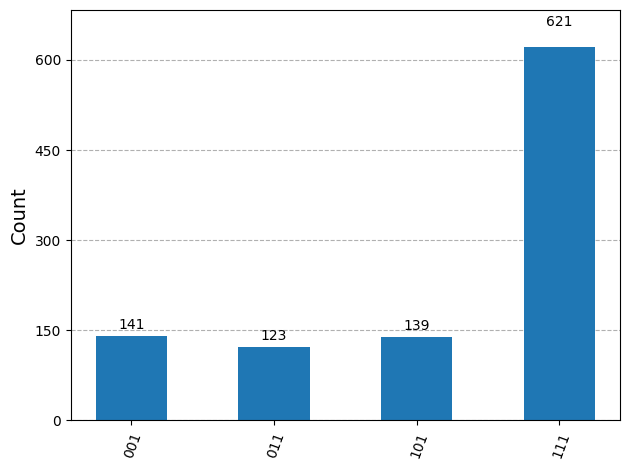

In [ ]:
coin = QuantumRegister(1, 'coin')
pos = QuantumRegister(3, 'pos')
c_pos = ClassicalRegister(3, 'meas')

qc = QuantumCircuit(coin, pos, c_pos)

def shift_right(qc, c, p):
    # Adder controlado por la moneda c=1
    qc.mcx([c, p[0], p[1]], p[2])
    qc.ccx(c, p[0], p[1])
    qc.cx(c, p[0])

def shift_left(qc, c, p):
    # Adder -, controlado por la moneda c=0
    qc.x(c) # Activar en 0
    qc.x(p) # Complemento a 2 para restar
    shift_right(qc, c, p)
    qc.x(p)
    qc.x(c)

# Ejecutar 3 iteraciones
for _ in range(3):
    qc.h(coin)
    # El shift operator actúa simultáneamente; al estar controlados
    # ortogonalmente (c=1 vs c=0), se pueden poner en secuencia sin estorbarse.
    shift_right(qc, coin, pos)
    shift_left(qc, coin, pos)
    qc.barrier()

qc.measure(pos, c_pos)

sim = AerSimulator()
qc_transpiled = transpile(qc, sim)
counts = sim.run(qc_transpiled, shots=1024).result().get_counts()

print(counts)
plot_histogram(counts)

## 4. QFT y QPE

### a) Demuestra a partir de la siguiente fórmula si la QFT es unitaria:

$$
\ket{x} \implies \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n-1} e^{\frac{2 \pi i x k }{2^n}} \ket{k}
$$

Debemos probar que la matriz $U_{QFT}$ cumple con $U_{QFT}^\dagger U_{QFT} = I$, o lo que es lo mismo: $\langle y | U_{QFT}^\dagger U_{QFT} | x \rangle = \delta_{xy}$.

Dado que $N = 2^n$, la transformación de un estado base se define como:
$$U_{QFT} |x\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i xk / N} |k\rangle$$

Tomamos un segundo estado base $|y\rangle$ y aplicamos la misma transformación:
$$U_{QFT} |y\rangle = \frac{1}{\sqrt{N}} \sum_{j=0}^{N-1} e^{2\pi i yj / N} |j\rangle$$

Calculamos el producto interno entre ambos estados transformados:
$$\langle y | U_{QFT}^\dagger U_{QFT} | x \rangle = \left( \frac{1}{\sqrt{N}} \sum_{j=0}^{N-1} e^{-2\pi i yj / N} \langle j | \right) \left( \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i xk / N} | k \rangle \right)$$

Como los estados base son ortonormales, $\langle j | k \rangle = \delta_{jk}$, la doble sumatoria colapsa a una sola sobre $k$:
$$\langle y | U_{QFT}^\dagger U_{QFT} | x \rangle = \frac{1}{N} \sum_{k=0}^{N-1} e^{2\pi i k (x-y) / N}$$

Entonces esta suma geométrica tiene 2 casos:
1.  **Si $x = y$**: El exponente es 0, por lo que cada término de la suma vale 1. El resultado es $\frac{1}{N} (N) = 1$.
2.  **Si $x \neq y$**: Usando la fórmula de la suma de una serie geométrica $\sum_{k=0}^{N-1} r^k = \frac{1-r^N}{1-r}$. Aquí $r = e^{2\pi i (x-y) / N}$.

    El numerador de la serie evaluada será $1 - e^{2\pi i (x-y)}$. Dado que $x$ e $y$ son enteros distintos en el rango $[0, N-1]$, su diferencia $(x-y)$ es un entero no nulo. La exponencial compleja de $2\pi i$ por un entero es siempre 1. Por tanto, el numerador es $1 - 1 = 0$.

El producto interno es exactamente $\delta_{xy}$. Esto demuestra que las columnas de la matriz son ortonormales.
$\blacksquare$

### b) Corre el algoritmo de QPE para 5 qubits en el primer registro para los siguientes valores de fase: 0.5, 0.125, 1/e, 1/pi


/tmp/ipykernel_6715/3591474791.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_inv = QFT(num_qubits=t, inverse=True, do_swaps=True).to_gate()


Valor de fase :[0.5] Ideal: 0.50000 -> Medido: 0.5
Valor de fase :[0.125] Ideal: 0.12500 -> Medido: 0.125
Valor de fase :[1/e] Ideal: 0.36788 -> Medido: 0.375
Valor de fase :[1/pi] Ideal: 0.31831 -> Medido: 0.3125


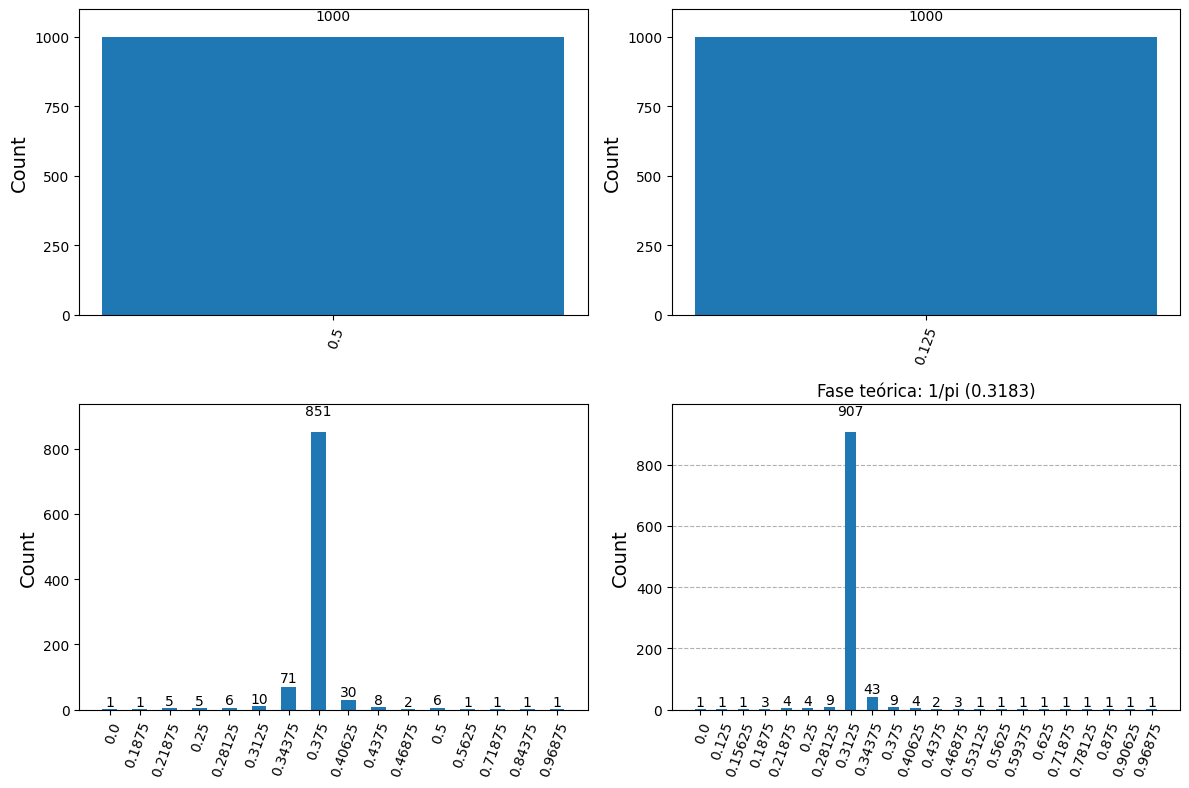

In [6]:
fases = {
    '0.5': 0.5,
    '0.125': 0.125,
    '1/e': 1/np.e,
    '1/pi': 1/np.pi
}

t = 5 # qubits
sim = AerSimulator()
resultados = {}

for nombre, theta in fases.items():
    qc = QuantumCircuit(t + 1, t)

    # |1> en el último qubit
    qc.x(t)

    # Superposicion
    for i in range(t):
        qc.h(i)

    # Phi = 2*pi*theta
    angulo_base = 2 * np.pi * theta
    for i in range(t):
        # Aplicamos la fase 2^i veces controlada por el qubit i
        angulo_aplicado = angulo_base * (2**i)
        qc.cp(angulo_aplicado, i, t)

    # Aplicamos QFT inversa
    qft_inv = QFT(num_qubits=t, inverse=True, do_swaps=True).to_gate()
    qc.append(qft_inv, range(t))

    # Medicion
    qc.measure(range(t), range(t))

    # Ejecutamos
    qc_transpiled = transpile(qc, sim)
    counts = sim.run(qc_transpiled, shots=1000).result().get_counts()

    # binario a decimal
    counts_decimal = {int(k, 2)/ (2**t): v for k, v in counts.items()}
    resultados[nombre] = counts_decimal

# Resultados
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (nombre, counts_dec) in enumerate(resultados.items()):
    counts_str = {str(k): v for k, v in counts_dec.items()}
    plot_histogram(counts_str, ax=axes[i], title=f"Fase teórica: {nombre} ({fases[nombre]:.4f})")

    fase_medida = max(counts_dec, key=counts_dec.get)
    print(f"Valor de fase :[{nombre}] Ideal: {fases[nombre]:.5f} -> Medido: {fase_medida}")

plt.tight_layout()
plt.show()

### c) Demostrar que las compuertas controladas de QPE aplican $\ket{j}\ket{\psi} \rightarrow \ket{j}U^j\ket{\psi}$

El primer registro $|j\rangle$ representa un número entero en binario. Si usamos $t$ qubits, entonces:

$$
j = j_0 2^0 + j_1 2^1 + \dots + j_{t-1}2^{t-1}
$$

donde cada $j_k$ vale 0 o 1 dependiendo del estado del qubit correspondiente.

Por eso el estado completo del registro puede escribirse como:

$$
|j\rangle = |j_{t-1}\rangle \otimes \dots \otimes |j_1\rangle \otimes |j_0\rangle
$$

En QPE, cada qubit de control aplica una versión controlada de $U$. El qubit $k$ controla la operación:

$$
U^{2^k}
$$

sobre el estado $|\psi\rangle$.

Entonces, para un solo qubit de control, el efecto es:

$$
C\text{-}U^{2^k} (|j_k\rangle |\psi\rangle) = |j_k\rangle (U^{2^k})^{j_k} |\psi\rangle
$$

Esto significa:

* si $j_k=0$, no se aplica nada
* si $j_k=1$, se aplica $U^{2^k}$

Como el circuito aplica todas estas compuertas sobre el mismo registro $|\psi\rangle$, el efecto total es multiplicar todas las potencias de $U$:

$$
\prod_{k=0}^{t-1} (U^{2^k})^{j_k}
$$

y como todas son potencias de la misma matriz $U$, los exponentes simplemente se suman:

$$
U^{\sum_{k=0}^{t-1} j_k 2^k}
$$

Pero justamente:

$$
\sum_{k=0}^{t-1} j_k 2^k = j
$$

porque así se construye el número binario $j$.

Entonces el resultado final queda:

$$
|j\rangle |\psi\rangle
\rightarrow
|j\rangle U^j |\psi\rangle
$$

$\blacksquare$


## 5) Investiga y contesta las siguientes preguntas con tus propias palabras

### a) Si el estado que colocar en el segundo registro en la QPE no fuera un eigenestado, si no una combinación lineal de multiples eigenestados, ¿Como se verían las cuentas que recuperes con la QPE? ¿Por que?

Si metemos una combinación lineal $|\psi\rangle = \sum c_i |u_i\rangle$ en el segundo registro, el circuito procesa todo en superposición. Al final, el estado queda entrelazado como $\sum c_i |\tilde{\phi}_i\rangle |u_i\rangle$. Si mides el registro de conteo, no verás un solo pico definido, sino un histograma con múltiples picos. Cada pico estará centrado en la fase $\tilde{\phi}_i$ de cada eigenestado que componía tu estado original. La probabilidad de medir cada fase será proporcional a $|c_i|^2$, que es el peso de ese eigenestado en la combinacion lineal.

**Ref:**
Nielsen, M. A., & Chuang, I. L. (2010). Quantum Computation and Quantum Information. Cambridge University Press.

### b) Investiga que es el QAOA y la formulación QUBO, asi como la transformación QUBO-
Ising. Busca en que problemas se ha aplicado para resolverse. Cita un ejemplo donde alguien

haya resuelto algún problema con ello
QAOA es un algoritmo híbrido cuántico-clásico para encontrar soluciones aproximadas a problemas de optimización combinatoria. El paper original lo propone para este tipo de problemas y lo prueba en MaxCut.

QUBO significa *Quadratic Unconstrained Binary Optimization*. Básicamente, se minimiza una función cuadrática con variables binarias $x_i \in \{0,1\}$.

La transformación QUBO-Ising cambia esas variables binarias por espines $s_i \in \{-1,1\}$. En D-Wave aparece como $s = 2x - 1$, o equivalentemente $x = (s+1)/2$. Eso permite escribir el costo como un Hamiltoniano tipo Ising con términos de Pauli-Z.

QAOA y QUBO-Ising se han aplicado en problemas como MaxCut, scheduling, logística y portfolio optimization. Un ejemplo concreto es *portfolio optimization*: el trabajo de 2022 lo formula como quadratic binary optimization y evalúa QAOA para ese problema.

Referencias

* Farhi, E., Goldstone, J., & Gutmann, S. (2014). *A Quantum Approximate Optimization Algorithm*. arXiv:1411.4028.
* Lucas, A. (2014). *Ising formulations of many NP problems*. arXiv:1302.5843.
* Brandhofer, S., et al. (2022). *Benchmarking the performance of portfolio optimization with QAOA*. arXiv:2207.10555.


### c) En corrección de errores, hemos visto 2 modelos para poder corregir 2 errores. Pero investiga el caso de la amplitude Damping. ¿Existe alguna forma de trabajar ese error? ¿Como? ¿Cuando se suele manifestar?

El *amplitude damping* ocurre cuando un qubit pierde energía hacia su entorno y decae del estado $|1\rangle$ al $|0\rangle$. En hardware real, esto se manifiesta físicamente como el proceso de relajación térmica (el famoso tiempo $T_1$), y es el error predominante en arquitecturas basadas en superconductores como las de IBM.

Sí se puede trabajar. Técnicamente puedes usar códigos genéricos de corrección de errores (como el de Shor de 9 qubits), pero es ineficiente porque gastas muchos recursos protegiendo contra errores simétricos. El *amplitude damping* es fuertemente asimétrico: el qubit cae a 0, pero casi nunca brinca de 0 a 1 por sí solo.

Para aprovechar esta asimetría, se diseñaron códigos específicos. El más representativo es el propuesto por Leung et al., que logra corregir este error de manera aproximada utilizando únicamente 4 qubits en total. Al estar optimizado solo para pérdida de amplitud, ahorra los qubits auxiliares que los métodos universales desperdician.

Referencias

* Leung, D. W., Nielsen, M. A., Chuang, I. L., & Yamamoto, Y. (1997). *Approximate quantum error correction can lead to better codes*.. arXiv:quant-ph/9704002.
* Chuang, I. L., Leung, D. W., & Yamamoto, Y. (1997). *Bosonic quantum codes for amplitude damping*. 1114.



### d) D-Wave tiene computadoras cuánticas no convencionales. ¿Que es lo que diferencía a las computadoras cuánticas de D-Wave con respecto del resto? ¿Podrías aplicar la formulación QUBO a ello?

La diferencia principal está en el modelo de cómputo. Las computadoras convencionales (IBM, Google) son universales y usan el modelo de compuertas lógicas cuánticas; programas algoritmos construyendo circuitos paso a paso. Las máquinas de D-Wave no usan compuertas, son "Quantum Annealers" diseñados específicamente para optimización.

En D-Wave te basas en el teorema adiabático: en lugar de armar un circuito, inicializas el hardware en un estado de mínima energía que es fácil de preparar. Luego dejas que el sistema evolucione lentamente hasta transformarse en el Hamiltoniano que modela tu problema. La solución la obtienes al medir los qubits en su estado base final.

QUBO es el lenguaje nativo para usar D-Wave. Para correr algo ahí, tomas tu problema QUBO, usas la transformación matemática a variables de Ising, y la API de D-Wave mapea directamente esos pesos y penalizaciones como acoplamientos magnéticos reales entre los qubits físicos de su procesador.

Referencias

* McGeoch, C. C. (2014). *Adiabatic Quantum Computation and Quantum Annealing: Theory and Practice*. Synthesis Lectures on Quantum Computing.
* Johnson, M. W., et al. (2011). *Quantum annealing with manufactured spins*. Nature.